In [1]:
from QLBM import QLBM, collision, InitializeQC
from QLBM_1 import QLBM1, collision1, InitializeQC1
from QLBM_2 import QLBM2, collision2, InitializeQC2
import numpy as np
import matplotlib.pyplot as plt
import qiskit_aer
from qiskit import transpile

In [2]:
# Domain and grid setup
N_POINTS_X, N_POINTS_Y = 8, 8
x_0 = np.arange(N_POINTS_X)
y_0 = np.arange(N_POINTS_Y)
X, Y = np.meshgrid(x_0, y_0)  # Create a 2D grid

# Simulation parameters
NUMBER_DISCRETE_VELOCITIES = 9  # D2Q9 lattice configuration

In [3]:
Q = 9

Nx = N_POINTS_X-1
Ny = N_POINTS_Y-1
dx = dy = 1.0
dt = dx
c = dt/dx
Re = 10
f_eq = np.zeros((Nx+1, Ny+1, Q))
f = np.zeros((Nx+1, Ny+1, Q))
f_qeq = np.zeros((Nx+1, Ny+1, Q))
fq = np.zeros((Nx+1, Ny+1, Q))

Lx = dx * float(Nx+1)/2
Ly = dy * float(Ny+1)/2
U = 0.2
cs = np.sqrt(c**2/3)
nu = U * Lx / Re
nu_star = dt/6

tau_f = 1.0
rho_0 = 1.0
rho = np.zeros((Nx+1, Ny+1))
rhoq = np.zeros((Nx+1, Ny+1))
u = np.zeros((Nx+1, Ny+1, 2))
uq = np.zeros((Nx+1, Ny+1, 2))
e = np.array([[0, 0], [1, 0], [0, 1], [-1, 0], [0, -1], [1, 1], [-1, 1], [-1, -1], [1, -1]])
w = np.array([4.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/36, 1.0/36, 1.0/36, 1.0/36])
u_n = u[:, :, 0].copy()
v_n = u[:, :, 1].copy() 

t_s = 1.0
TIMESTEPS = int(t_s*Lx/U)
print(nu,nu_star,nu-nu_star,Nx+1,Re)
print(Nx+1,TIMESTEPS,U,Lx)
q_error = []
c_error = []
qc_error = []

0.08 0.16666666666666666 -0.08666666666666666 8 10
8 20 0.2 4.0


In [4]:
##Initial
x0 = np.linspace(-Lx+dx/2,Lx-dx/2,Nx+1)
print(x0)
y0 = np.linspace(-Ly+dx/2,Ly-dx/2,Ny+1)
X0,Y0 = np.meshgrid(x0,y0)
rho[:, :] = rho_0
u[:, :, 0] = -U*np.cos(np.pi*X0/Lx)*np.sin(np.pi*Y0/Ly)
u[:, :, 1] = U*np.sin(np.pi*X0/Lx)*np.cos(np.pi*Y0/Ly)

[-3.5 -2.5 -1.5 -0.5  0.5  1.5  2.5  3.5]


In [5]:
simulator = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()
simulator1 = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()
simulator2 = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()

In [6]:
def possion(u_hat,delta_x):
    vor = np.zeros((u_hat.shape[0]+2,u_hat.shape[1]+2))
    vor[1:-1,1:-1] = u_hat
    vor[0,1:-1] = vor[-2,1:-1]
    vor[-1,1:-1] = vor[1,1:-1]
    vor[:,0] = vor[:,-2]
    vor[:,-1] = vor[:,1]
    vor1 =(vor[1:-1,0:-2]+vor[1:-1,2:] + vor[0:-2,1:-1] + vor[2:,1:-1]-4.0*vor[1:-1,1:-1])/delta_x**2

    return vor1

In [7]:
# Initialize the quantum LBM scalar field
Psi_qlbm = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm1 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm2 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm[0, :, :] = rho_0#Psi_init
Psi_qlbm1[0, :, :] = u[:,:,0].copy()#Psi_init
Psi_qlbm2[0, :, :] = u[:,:,1].copy()#Psi_init
Psi_qlbm0 = Psi_qlbm[0,:,:].copy()
u_LBM = np.zeros((N_POINTS_X, N_POINTS_Y, 2))
u_LBM[:, :, 0] = Psi_qlbm1[0,:,:]  # Set the x-component of the velocity
u_LBM[:, :, 1] = Psi_qlbm2[0,:,:]  # Set the y-component of the velocity

In [8]:
# Quantum LBM simulation loop
for t in range(TIMESTEPS):

    u_d= possion(u[:,:,0],dx)
    v_d= possion(u[:,:,1],dx)
    temp = u[:, :, 0] * u[:, :, 0] + u[:, :, 1] * u[:, :, 1]
    f_eq[:, :, 0] = w[0] * rho* (1.0 + 3.0 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) + 4.5 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 1] = w[1] * rho* (1.0 + 3.0 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) + 4.5 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 2] = w[2] * rho* (1.0 + 3.0 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) + 4.5 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 3] = w[3] * rho* (1.0 + 3.0 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) + 4.5 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 4] = w[4] * rho* (1.0 + 3.0 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) + 4.5 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 5] = w[5] * rho* (1.0 + 3.0 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) + 4.5 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 6] = w[6] * rho* (1.0 + 3.0 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) + 4.5 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 7] = w[7] * rho* (1.0 + 3.0 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) + 4.5 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 8] = w[8] * rho* (1.0 + 3.0 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) + 4.5 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)

    f[:, :, 0] = f[:, :, 0] - (f[:, :, 0] - f_eq[:, :, 0]) / tau_f
    f[:, :, 1] = f[:, :, 1] - (f[:, :, 1] - f_eq[:, :, 1]) / tau_f
    f[:, :, 2] = f[:, :, 2] - (f[:, :, 2] - f_eq[:, :, 2]) / tau_f
    f[:, :, 3] = f[:, :, 3] - (f[:, :, 3] - f_eq[:, :, 3]) / tau_f
    f[:, :, 4] = f[:, :, 4] - (f[:, :, 4] - f_eq[:, :, 4]) / tau_f
    f[:, :, 5] = f[:, :, 5] - (f[:, :, 5] - f_eq[:, :, 5]) / tau_f
    f[:, :, 6] = f[:, :, 6] - (f[:, :, 6] - f_eq[:, :, 6]) / tau_f
    f[:, :, 7] = f[:, :, 7] - (f[:, :, 7] - f_eq[:, :, 7]) / tau_f
    f[:, :, 8] = f[:, :, 8] - (f[:, :, 8] - f_eq[:, :, 8]) / tau_f

    ##streaming
    for i in range(9):
        f[:,:,i] = np.roll(f[:,:,i], shift=e[i,0], axis=0)
        f[:,:,i] = np.roll(f[:,:,i], shift=e[i,1], axis=1)

    rho = f[:, :, 0] + f[:, :, 1] +f[:, :, 2]+f[:, :, 3]+f[:, :, 4]+f[:, :, 5]+f[:, :, 6]+f[:, :, 7]+f[:, :, 8]
    u[:, :, 0] = (f[:, :, 1] - f[:, :, 3] + f[:, :, 5] - f[:, :, 6] - f[:, :, 7] + f[:, :, 8]) / rho
    u[:, :, 1] = (f[:, :, 2] - f[:, :, 4] + f[:, :, 5] + f[:, :, 6] - f[:, :, 7] - f[:, :, 8]) / rho
    u[:, :, 0] = u[:, :, 0] + dt*(nu-nu_star)*u_d
    u[:, :, 1] = u[:, :, 1] + dt*(nu-nu_star)*v_d

    u_pd= possion(Psi_qlbm1[t,:,:],dx)
    v_pd= possion(Psi_qlbm2[t,:,:],dx)
    # Create and run the quantum circuit for LBM, rho
    qc = QLBM(density_field=Psi_qlbm[t, :, :], velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit = transpile(qc, simulator)
    result = simulator.run(compiled_circuit).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector = np.array(result.get_statevector())
    real_part_statevector = np.real(statevector[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped = np.reshape(real_part_statevector, (N_POINTS_X, N_POINTS_Y), order='F')
    
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm[t + 1, :, :] = real_part_statevector_reshaped * np.linalg.norm(Psi_qlbm[t, :, :].flatten()) * 4

    # Create and run the quantum circuit for LBM, u
    qc1 = QLBM1(density_field=Psi_qlbm0, velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit1 = transpile(qc1, simulator1)
    result1 = simulator1.run(compiled_circuit1).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector1 = np.array(result1.get_statevector())
    real_part_statevector1 = np.real(statevector1[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped1 = np.reshape(real_part_statevector1, (N_POINTS_X, N_POINTS_Y), order='F')
    
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm1[t + 1, :, :] = real_part_statevector_reshaped1 * np.linalg.norm(Psi_qlbm0.flatten()) * 4 / Psi_qlbm0

    # Create and run the quantum circuit for LBM, u
    qc2 = QLBM2(density_field=Psi_qlbm0, velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit2 = transpile(qc2, simulator2)
    result2 = simulator2.run(compiled_circuit2).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector2 = np.array(result2.get_statevector())
    real_part_statevector2 = np.real(statevector2[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped2 = np.reshape(real_part_statevector2, (N_POINTS_X, N_POINTS_Y), order='F')
    
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm2[t + 1, :, :] = real_part_statevector_reshaped2 * np.linalg.norm(Psi_qlbm0.flatten()) * 4 / Psi_qlbm0
    Psi_qlbm1[t + 1,:, :] = Psi_qlbm1[t + 1,:, :] + dt*(nu-nu_star)*u_pd
    Psi_qlbm2[t + 1,:, :] = Psi_qlbm2[t + 1,:, :] + dt*(nu-nu_star)*v_pd
    Psi_qlbm0 = Psi_qlbm[t + 1, :, :].copy()
    
    error = np.sum(np.sqrt((u_n-u[:, :, 0])**2+(v_n-u[:, :, 1])**2))/np.sum(np.sqrt(u[:, :, 0]**2+u[:, :, 1]**2))
    u_n = u[:, :, 0].copy() 
    v_n = u[:, :, 1].copy()

    u_LBM[:,:,0] = Psi_qlbm1[t + 1, :, :]
    u_LBM[:,:,1] = Psi_qlbm2[t + 1, :, :]
    error1 = np.sum(np.sqrt((Psi_qlbm1[t + 1, :, :]-Psi_qlbm1[t, :, :])**2+(Psi_qlbm2[t + 1, :, :]-Psi_qlbm2[t, :, :])**2))/np.sum(np.sqrt(Psi_qlbm1[t + 1, :, :]**2+Psi_qlbm2[t + 1, :, :]**2))
    error2 = np.sum(np.sqrt((Psi_qlbm1[t + 1, :, :]-u_n)**2+(Psi_qlbm2[t + 1, :, :]-v_n)**2))/np.sum(np.sqrt(u_n**2+v_n**2))

    print(t, error, error1, error2)

0 1.0 0.12765310792913123 0.005543116893730455
1 0.11557189340976 0.11799147146390421 0.011001460144758344
2 0.13126164843743035 0.13247683725172313 0.008786393694864031
3 0.11199631592411793 0.11027677774563616 0.006046162904549265
4 0.09824341306382281 0.09726656571844178 0.003233773199651844
5 0.10149093103942633 0.10071975024874641 0.0036396070352307454
6 0.10385551204276168 0.10305917751801838 0.004202389787602657
7 0.10366137993872385 0.10329904923057788 0.003452431565203063
8 0.1039366200086448 0.10379752347431345 0.0026205966561302137
9 0.10394305095406822 0.1038689752693301 0.0022179945087846863
10 0.10336297371656872 0.1033553236884387 0.002037293167213494
11 0.1030281561498064 0.10301969132911476 0.0019118112929535328
12 0.10311414674725122 0.10307567680728291 0.0017540709054129442
13 0.10327561927265452 0.10323884297370743 0.0015439171485213674
14 0.10337101166376605 0.1033545422731856 0.0013060527192214218
15 0.10341098561960177 0.1034066649661142 0.001075519134924372
16 0

In [9]:
u_exact = -U*np.cos(np.pi*X0/Lx)*np.sin(np.pi*Y0/Ly)*np.exp(-2.0*np.pi**2*t_s/(Re))
v_exact = U*np.sin(np.pi*X0/Lx)*np.cos(np.pi*Y0/Ly)*np.exp(-2.0*np.pi**2*t_s/(Re))

print(np.sqrt(np.sum((np.abs(u_exact)/U-np.abs(u[:, :, 0])/U)**2)/((Nx+1)*(Ny+1))))
print(np.sqrt(np.sum((np.abs(v_exact)/U-np.abs(u[:, :, 1])/U)**2)/((Nx+1)*(Ny+1))))
print(np.sqrt(np.sum((np.abs(u_exact)/U-np.abs(Psi_qlbm1[t+1,:, :])/U)**2)/((Nx+1)*(Ny+1))))
print(np.sqrt(np.sum((np.abs(v_exact)/U-np.abs(Psi_qlbm2[t+1,:, :])/U)**2)/((Nx+1)*(Ny+1))))

0.0003691003791362836
0.0003691003791362662
0.00038899608359404923
0.00038899608359380464


In [ ]:
np.savetxt("Re=10_8\QLBM_u_2.csv",Psi_qlbm1[t+1,:,:],delimiter=",")
np.savetxt("Re=10_8\QLBM_v_2.csv",Psi_qlbm2[t+1,:,:],delimiter=",")
np.savetxt("Re=10_8\QLBM_rho_2.csv",Psi_qlbm[t+1,:,:],delimiter=",")
np.savetxt("Re=10_8\CLBM_u_2.csv",u[:,:,0],delimiter=",")
np.savetxt("Re=10_8\CLBM_v_2.csv",u[:,:,1],delimiter=",")
np.savetxt("Re=10_8\CLBM_rho_2.csv",rho,delimiter=",")

In [10]:
print(t, error, error1, error2)

19 0.10338411331620337 0.10338356661429342 0.0005279464641340413


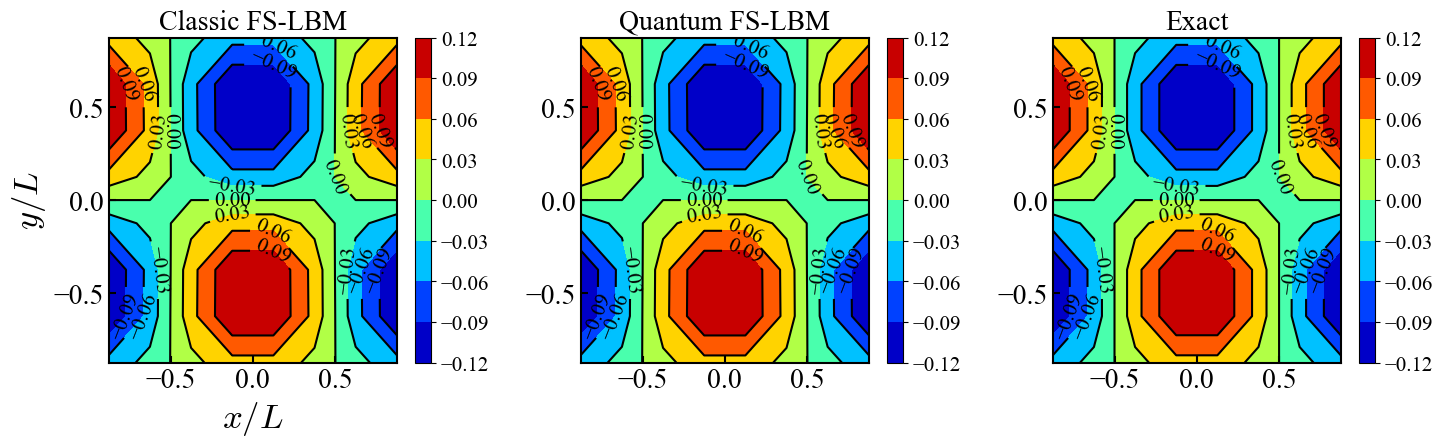

In [11]:
import matplotlib
font = {'family': 'Times New Roman',}
font1 = {'family': 'Times New Roman','style': 'italic',}
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'

fig = plt.figure(figsize=(20, 5))
ax1 = plt.axes([0.056, 0.2, 0.18, 0.65])
ax01=plt.contourf(X0/Lx,Y0/Lx,u[:,:,0]/U, 8,cmap='jet')
ax001 = plt.colorbar(ax01)
ax001.ax.tick_params(labelsize=15)
CS=plt.contour(X0/Lx,Y0/Lx,u[:,:,0]/U,8,colors='k',linestyles='-',zorder=10)
ax1.clabel(CS, inline=True, fontsize=15)
ax1.set_xlabel('$x/L$', size = 25,fontdict = font1)
ax1.set_ylabel('$y/L$', size = 25,fontdict = font1)    
ax1.set_title('Classic FS-LBM', fontsize = 20,fontdict = font)
ax1.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax1.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)

ax2 = plt.axes([0.292, 0.2, 0.18, 0.65])
ax02=plt.contourf(X0/Lx,Y0/Lx,Psi_qlbm1[t+1,:,:]/U, 8,cmap='jet')
ax002 = plt.colorbar(ax02)
ax002.ax.tick_params(labelsize=15)
CS1=plt.contour(X0/Lx,Y0/Lx,Psi_qlbm1[t+1,:,:]/U,8,colors='k',linestyles='-',zorder=10)
ax2.clabel(CS1, inline=True, fontsize=15)
ax2.set_title('Quantum FS-LBM', fontsize = 20,fontdict = font)
ax2.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax2.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)


ax3 = plt.axes([0.528, 0.2, 0.18, 0.65])
ax03=plt.contourf(X0/Lx,Y0/Lx,u_exact/U, 8,cmap='jet')
ax003 = plt.colorbar(ax03)
ax003.ax.tick_params(labelsize=15)
CS2=plt.contour(X0/Lx,Y0/Lx,u_exact/U,8,colors='k',linestyles='-',zorder=10)
ax3.clabel(CS2, fontsize=15,colors='k')
ax3.set_title('Exact', fontsize = 20,fontdict = font)
ax3.tick_params(labelsize=20)

ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax3.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)

#plt.savefig('plot_u.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

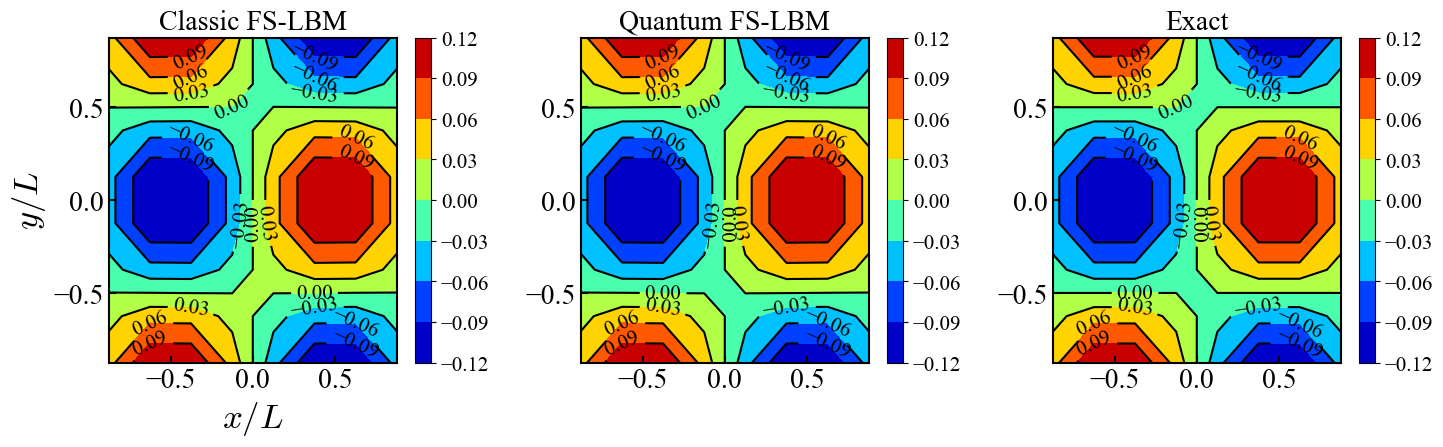

In [12]:
import matplotlib
font = {'family': 'Times New Roman',}
font1 = {'family': 'Times New Roman','style': 'italic',}
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'

fig = plt.figure(figsize=(20, 5))
ax1 = plt.axes([0.056, 0.2, 0.18, 0.65])
ax01=plt.contourf(X0/Lx,Y0/Lx,u[:,:,1]/U, 8,cmap='jet')
ax001 = plt.colorbar(ax01)
ax001.ax.tick_params(labelsize=15)
CS=plt.contour(X0/Lx,Y0/Lx,u[:,:,1]/U,8,colors='k',linestyles='-',zorder=10)
ax1.clabel(CS, inline=True, fontsize=15)
ax1.set_xlabel('$x/L$', size = 25,fontdict = font1)
ax1.set_ylabel('$y/L$', size = 25,fontdict = font1)    
ax1.set_title('Classic FS-LBM', fontsize = 20,fontdict = font)
ax1.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax1.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)

ax2 = plt.axes([0.292, 0.2, 0.18, 0.65])
ax02=plt.contourf(X0/Lx,Y0/Lx,Psi_qlbm2[t+1,:,:]/U, 8,cmap='jet')
ax002 = plt.colorbar(ax02)
ax002.ax.tick_params(labelsize=15)
CS1=plt.contour(X0/Lx,Y0/Lx,Psi_qlbm2[t+1,:,:]/U,8,colors='k',linestyles='-',zorder=10)
ax2.clabel(CS1, inline=True, fontsize=15)
ax2.set_title('Quantum FS-LBM', fontsize = 20,fontdict = font)
ax2.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax2.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)


ax3 = plt.axes([0.528, 0.2, 0.18, 0.65])
ax03=plt.contourf(X0/Lx,Y0/Lx,v_exact/U, 8,cmap='jet')
ax003 = plt.colorbar(ax03)
ax003.ax.tick_params(labelsize=15)
CS2=plt.contour(X0/Lx,Y0/Lx,v_exact/U,8,colors='k',linestyles='-',zorder=10)
ax3.clabel(CS2, fontsize=15,colors='k')
ax3.set_title('Exact', fontsize = 20,fontdict = font)
ax3.tick_params(labelsize=20)

ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax3.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)

#plt.savefig('plot_v.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()